# Roller Coaster Continuous Model


The program computes the motion of a roller coaster
in a continuous elastic band model.

## Gaussian Mountain Profile

$$
h(x) = H e^{-a^2 x^2}
$$

$$
h'(x) = -2 a^2 x H e^{-a^2 x^2}
$$

$$
h''(x) = 2 a^2 (2 a^2 x^2 - 1) H e^{-a^2 x^2}
$$

In [2]:
import numpy as np
import matplotlib.pyplot as plt

## Parameters

In [3]:
H = 8                           # Mountain height
B = 10                          # Mountain width
a = np.sqrt(np.log(2)) / B      # Gaussian parameter
g = 9.81                        # Gravitational acceleration

L = 10.0                        # Train length in m
rho = 500                       # Mass density per unit length (kg/m)
Phi = 100000                    # Elastic modulus per unit length

NG = 1001                       # Material grid points
dl = L / (NG - 1)               # Distance between material grid points
l = np.linspace(0, L, NG)

Tmax = 6 * np.sqrt(2 * H / g)   # Maximum time
NT = 100001                     # Time steps
dt = Tmax / (NT - 1)            # Time step size
t = np.linspace(0, Tmax, NT)    # Time grid

## Gaussian Functions

In [3]:
def gauss(x, a, H):
    return H * np.exp(-a**2 * x**2)

def hp(x, a, H):
    return -2 * a**2 * x * gauss(x, a, H)

def h2p(x, a, H):
    return 2 * a**2 * (2 * a**2 * x**2 - 1) * gauss(x, a, H)

## Initial Conditions

Initial relaxed configuration:

$$
x_i(0) = l_i - \frac{4}{a}
$$

Second time step (velocity from energy conservation):

$$
v = \sqrt{\frac{2 g (H - h(x))}{1 + (h'(x))^2}}
$$

In [4]:
x = np.zeros((NT, NG))

# Initial condition (train is relaxed)
x[0, :] = l - 4/a

# Second time step for second order ODE
for i in range(NG):
    dhdx = hp(x[0, i], a, H)
    velocity = 1.018 * np.sqrt(2 * g * (H - gauss(x[0, i], a, H)) / (1 + dhdx**2))
    x[1, i] = x[0, i] + velocity * dt

## Finite Difference Scheme

Discretized equation of motion:

$$
x_i^{n+1} = 2x_i^n - x_i^{n-1} - c (\Delta_t x)^2 - g b \Delta t^2
+ \frac{\Phi}{\rho} \left(\frac{\Delta t}{\Delta l}\right)^2
( c (\Delta_l x)^2 + \Delta_l^2 x )
$$

with

$$
b = \frac{h'}{1+(h')^2}, \quad
c = h'' b
$$

In [5]:
for j in range(2, NT):

    x_prev  = x[j-1]
    x_prev2 = x[j-2]

    # Derivatives of mountain profile (vectorized)
    dhdx   = hp(x_prev[1:-1], a, H)
    d2hdx2 = h2p(x_prev[1:-1], a, H)

    b = dhdx / (1 + dhdx**2)
    c = d2hdx2 * b

    # Finite differences (vectorized)
    dxdt   = x_prev[1:-1] - x_prev2[1:-1]
    dxdl   = x_prev[1:-1] - x_prev[:-2]
    d2xdl2 = x_prev[2:] + x_prev[:-2] - 2*x_prev[1:-1]

    # Time stepping
    x[j,1:-1] = (
        2*x_prev[1:-1] - x_prev2[1:-1]
        - c * dxdt**2
        - g * b * dt**2
        + Phi/rho * (dt/dl)**2 * (c * dxdl**2 + d2xdl2)
    )

    # Boundary conditions
    x[j,0]  = x[j,1] - dl
    x[j,-1] = x[j,-2] + dl


## Visualization

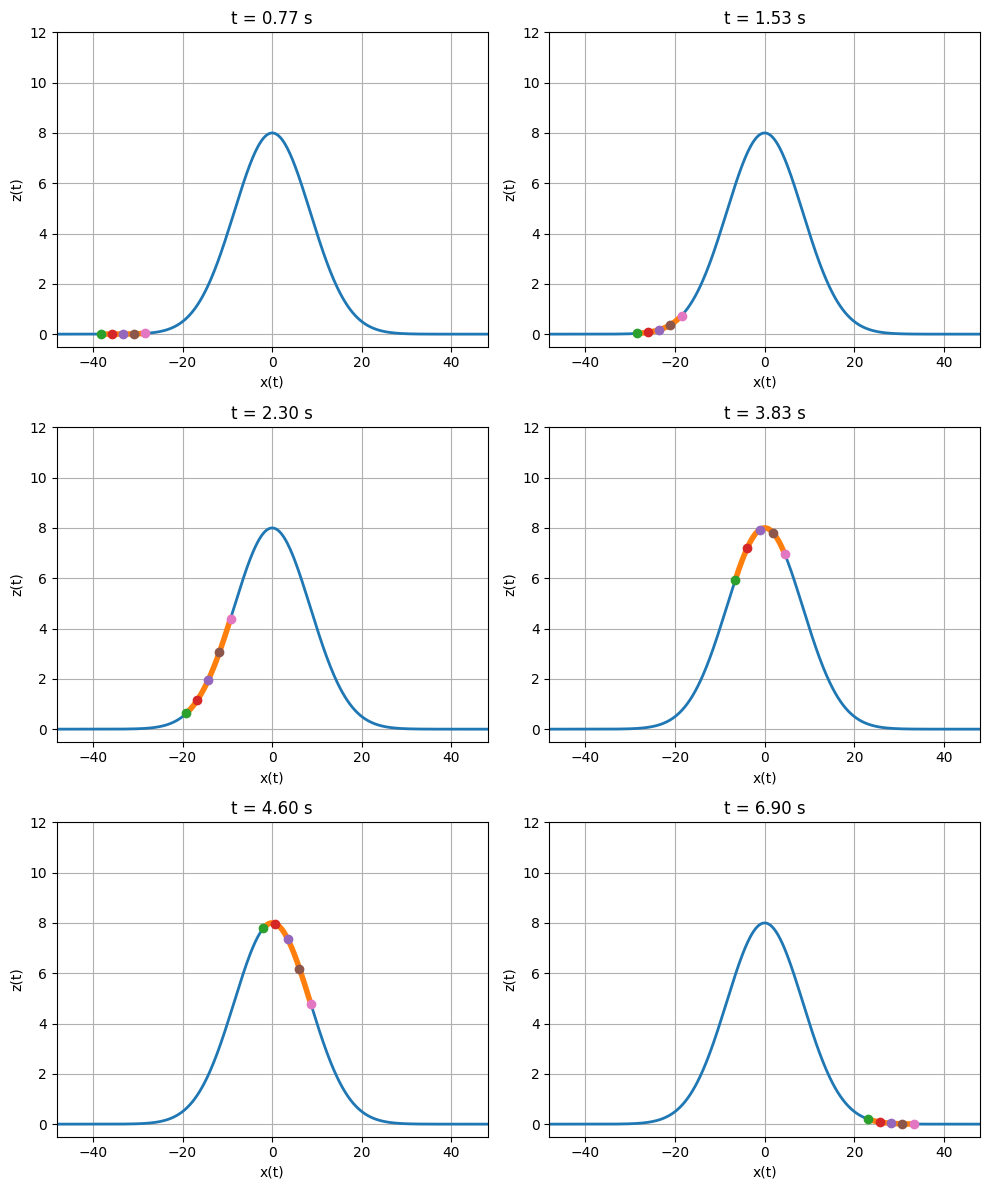

In [6]:
xplot = np.linspace(-4/a, 4/a, 500)
k = [10000, 20000, 30000, 50000, 60000, 90000]
pos = [0, 250, 500, 750, 1000]

plt.figure(figsize=(10,12))

for idx in range(6):
    plt.subplot(3,2,idx+1)
    plt.plot(xplot, gauss(xplot, a, H), linewidth=2)
    plt.plot(x[k[idx],:], gauss(x[k[idx],:], a, H), linewidth=4)
    
    for j in pos:
        plt.plot(x[k[idx], j], gauss(x[k[idx], j], a, H), 'o')

    plt.grid(True)
    plt.axis([-4/a, 4/a, -0.5, 1.5*H])
    plt.xlabel('x(t)')
    plt.ylabel('z(t)')
    plt.title(f't = {t[k[idx]]:.2f} s')

plt.tight_layout()
plt.show()